# Assignment 3 – Regression and Data Simulation

**Statistical Learning and Data Analysis**

In [22]:
# Importing required libraries 

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display, Math
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.graphics.gofplots import qqplot
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNetCV, ElasticNet
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
from statsmodels.nonparametric.smoothers_lowess import lowess


In [24]:
# defining functions 

def generate_linear_or_nonlinear_data(func, n_points=100, n_predictors=1,
                                      beta=None,
                                      low=-5, high=5, seed=123):
    if seed is not None:
        np.random.seed(seed)
    X = np.random.uniform(low, high, size=(n_points, n_predictors))
    f_val = func(X, beta)
    noise = np.random.normal(0, 1, size=n_points)
    y = f_val + noise
    return X, y

def f_linear(X, beta):
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return beta[0] + X @ beta[1:]

---

## Part 1 – Data Set Simulation and Linear Regression

In this part, I:
- Simulate a linear dataset with n=300 observations and p=10 predictors
- Fit an OLS linear regression model
- Analyze statistical significance of predictors
- Perform regression diagnostics
- Identify high leverage points, influential observations, and outliers

### 1.1 Generating the Linear Dataset and Defining the Model

I'll simulate data from the following linear model:

$$y_i = \beta_0 + \sum_{j=1}^{10} \beta_j X_{ij} + \varepsilon_i$$

where $X_{ij}$ are the predictors and $\varepsilon_i$ is the random error.

I choose the following coefficient vector:
$$\beta = (2.0, 3.7, 0.2, 0.0, 0.0, -2.3, 0.0, 0.1, 0.0, 3.1, 0)$$
Having that my generating function is:
$$
y_i = 2.0 + 3.7 X_{i1} + 0.2 X_{i2} - 2.3 X_{i5} + 0.1 X_{i7} + 3.1 X_{i9} + \varepsilon_i
$$


In [28]:
# 1. Simulate data
beta_linear = np.array([
    2.0,  # intercept
    3.7,  # x1 strong
    0.2,  # x2 weak
    0.0,  # x3 
    0.0,  # x4 
    -2.3, # x5 strong
    0.0,  # x6 
    0.1,  # x7 weak
    0.0,  # x8 
    3.1,  # x9 strong
    0.0   # x10 
])
n_predictors = 10
n_points_p1 = 300

print(f"Generating linear data with n={n_points_p1}, p={n_predictors}")
print(f"Beta Linear: {beta_linear}")

X, y = generate_linear_or_nonlinear_data(
    func=f_linear,
    n_points=n_points_p1,
    n_predictors=n_predictors,
    beta=beta_linear,
    seed=42
)

# Put into a DataFrame (useful for regression later)
columns = [f"X{i+1}" for i in range(10)]
df = pd.DataFrame(X, columns=columns)
df["y"] = y
print(f"Generated Dataset")
df.head()

Generating linear data with n=300, p=10
Beta Linear: [ 2.   3.7  0.2  0.   0.  -2.3  0.   0.1  0.   3.1  0. ]
Generated Dataset


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,y
0,-1.254599,4.507143,2.319939,0.986585,-3.439814,-3.440055,-4.419164,3.661761,1.011150,2.080726,9.923570
1,-4.794155,4.699099,3.324426,-2.876609,-3.181750,-3.165955,-1.957578,0.247564,-0.680550,-2.087709,-9.168984
2,1.118529,-3.605061,-2.078554,-1.336382,-0.439300,2.851760,-3.003262,0.142344,0.924146,-4.535496,9.676030
3,1.075449,-3.294759,-4.349484,4.488855,4.656320,3.083973,-1.953862,-4.023279,1.842330,-0.598475,-1.239447
4,-3.779618,-0.048231,-4.656115,4.093204,-2.412200,1.625223,-1.882889,0.200680,0.467103,-3.151455,-3.974497


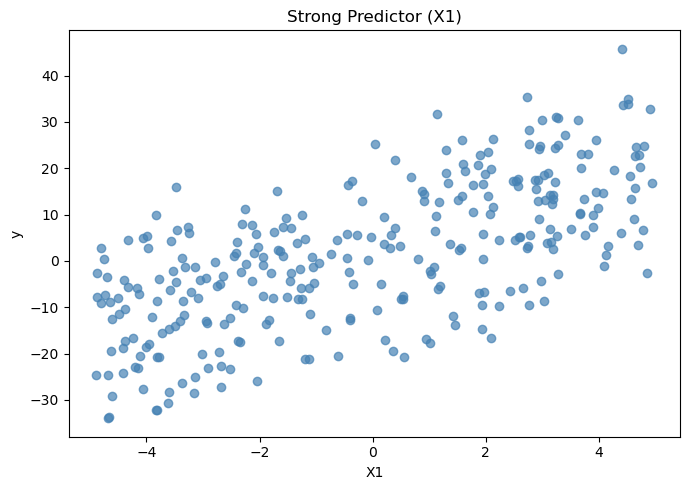

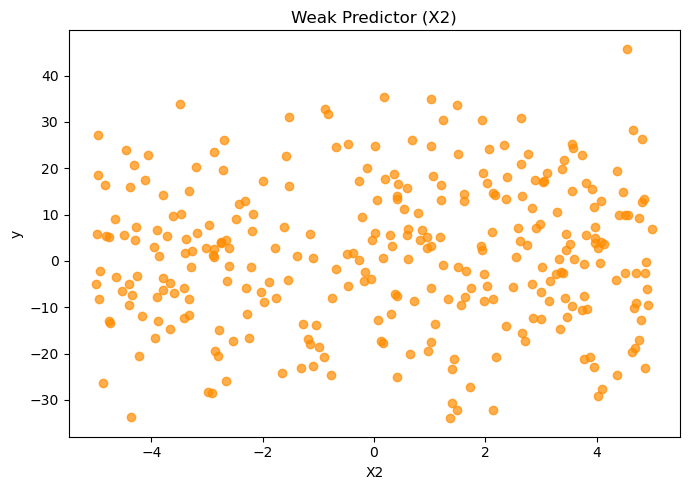

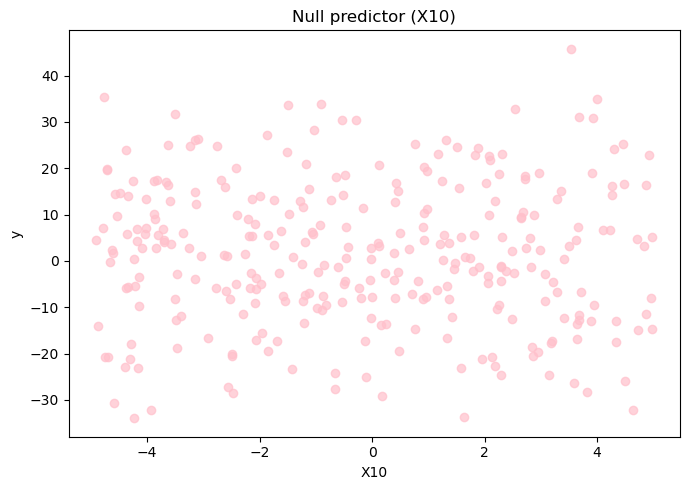

In [134]:
# Plotting Generated data

# Strong predictor
plt.figure(figsize=(7, 5))
plt.scatter(df["X1"], df["y"], alpha=0.7, color="steelblue")
plt.xlabel("X1")
plt.ylabel("y")
plt.title("Strong Predictor (X1)")
plt.tight_layout()
plt.show()

# Weak predictor
plt.figure(figsize=(7, 5))
plt.scatter(df["X2"], df["y"], alpha=0.7, color="darkorange")
plt.xlabel("X2")
plt.ylabel("y")
plt.title("Weak Predictor (X2)")
plt.tight_layout()
plt.show()

# Null predictor
plt.figure(figsize=(7, 5))
plt.scatter(df["X10"], df["y"], alpha=0.7, color="pink")
plt.xlabel("X10")
plt.ylabel("y")
plt.title("Null predictor (X10)")
plt.tight_layout()
plt.show()



**Justification**

1. **Strong predictors** ($X_1, X_5, X_9$ with coefficients 3.7, -2.3, 3.1): these represent important variables with large effects on the response. In the scatterplot, we can see that the pattern is almost linear, because $X_1$ is strongly correlated with $y$.
2. **Weak predictors** ($X_2, X_7$ with coefficients 0.2, 0.1): these have small but non-zero effects, testing whether the model can detect weak signals. In the scatterplot, we see that $X_2$ has almost no relationship with $y$, showing a correlation that it's extremly weak.
3. **Null predictors** ($X_3, X_4, X_6, X_8, X_{10}$ with coefficient 0.0): These are pure noise variables with no true relationship to the response. The scatterplot shows that the points are purely random, with no visible structure, meaning that $X_10$ contains no correlation with $y$.

Only three predictors are assigned large coefficients in order to represent a sparse regression setting, where only a subset of available variables has a meaningful effect on the response.
This reflects realistic applied scenarios, especially in high-dimensional problems, where many predictors may be irrelevant.
The coefficients were chosen with different magnitudes and signs to generate both positive and negative effects that are clearly detectable by regression models.

This structure allows us to evaluate:
- whether OLS correctly identifies strong signals;
- whether weak signals are detected (depends on sample size and noise);
- whether null predictors are correctly deemed non-significant.

**Randomness and Error**
I generated the predictors randomly to imitate real data, where variables naturally vary across observations, and I also added random noise to the response to represent things we cannot measure or explain, so the relationship is not perfectly predictable.
In particular:
- **predictor randomness**, the predictors $X_j$ are independently generated from a $Uniform(-5, 5)$ distribution
- **irreducible error**, the Gaussian noise $\varepsilon \sim \mathcal{N}(0,1)$ introduces variability that cannot be explained by the predictors.

The implications are that:
  - even with the correct model, the coefficient of determination $R^2$ will always be less than 1, meaning that the model will never explain $100%$ of the variability in $y$. This is because random noise cannot be predicted or explained by the model;
  - because the predictors and the error term are randomly generated, coefficient estimates change from sample to sample, reflecting sampling variability even when the true underlying model is fixed;
  - due to random noise, null predictors may occasionally appear weakly significant by chance (Type I error).

### 1.2 Fitting the Linear Regression Model and Reporting Results

I fit an Ordinary Least Squares (OLS) linear regression model using all 10 predictors plus an intercept:

$$\hat{y} = \hat{\beta}_0 + \sum_{j=1}^{10} \hat{\beta}_j X_j$$

The model recovers coefficient estimates close to the true values. Below I'll report:
- **Estimated coefficients** ($\hat{\beta}_j$);
- **Standard errors** (uncertainty in each estimate);
- **t-statistics** (coefficient divided by its standard error);
- **p-values** (probability of observing the estimate if true coefficient is zero).

In [136]:
# Predictors and response
X_reg = df[columns]
y_reg = df["y"]

# Add intercept
X_reg_const = sm.add_constant(X_reg)

# Fit linear regression model
linear_model = sm.OLS(y_reg, X_reg_const).fit()

# Get confidence intervals
conf_int = linear_model.conf_int()
conf_int.columns = ["CI Lower", "CI Upper"]

# ##1.2 fit linear regression
results_table = pd.DataFrame({
    "Coefficient": linear_model.params,
    "Std. Error": linear_model.bse,
    "t-statistic": linear_model.tvalues,
    "p-value": linear_model.pvalues,
    "CI Lower": conf_int["CI Lower"],
    "CI Upper": conf_int["CI Upper"],
    "True beta": beta_linear
})

# Display the table
results_table = results_table.round(4)
results_table

,Coefficient,Std. Error,t-statistic,p-value,CI Lower,CI Upper,True beta
const,2.0098,0.0581,34.5957,0.0000,1.8954,2.1241,2.0
X1,3.6973,0.0195,189.5572,0.0000,3.6590,3.7357,3.7
X2,0.1604,0.0192,8.3745,0.0000,0.1227,0.1981,0.2
X3,0.0047,0.0201,0.2352,0.8142,-0.0348,0.0442,0.0
X4,0.0044,0.0206,0.2123,0.8320,-0.0362,0.0449,0.0
X5,-2.2975,0.0192,-119.6579,0.0000,-2.3353,-2.2597,-2.3
X6,0.0283,0.0196,1.4488,0.1485,-0.0102,0.0669,0.0
X7,0.0844,0.0197,4.2926,0.0000,0.0457,0.1231,0.1
X8,0.0120,0.0206,0.5845,0.5593,-0.0284,0.0525,0.0
X9,3.0892,0.0193,160.0473,0.0000,3.0512,3.1272,3.1


The table above summarises the results of the fitted linear regression model, having that each row corresponds to a predictor variable and each column reports statistical information about its estimated effect on the response variable. Also, I included the true coefficients used to generate the data to compare the estimated values with the true ones.

**Coefficient (estimated $\beta$)**

This is the estimated effect of each predictor on the response variable:
- *strong predictors* ($X_1, X_5, X_9$) have large estimated coefficients close to the true values because their effects are much larger than the random noise and, as a result, the regression model can clearly detect and accurately estimate their influence on $y$;
- *weak predictors* ($X_2, X_7$), have an effect that is similar in size to random noise and noise can easily distort the estimate, so estimated coefficients can deviate more from the true value;
- *null predictors* ($X_3, X_4, X_6, X_8, X_{10}$), on the other hand, have estimated coefficients that are pure random noise, sometimes slightly positive, sometimes negative, though they are typically not statistically significant.

**Standard Error**

It measures how uncertain the estimated coefficient is, having that:
- if the standard error is small, the estimate is stable anr reliable;
- if it's large, the estimate is noisy and unreliable.

Considering that big and small values are relative to the coefficient size, it's best to take a look at the t-statistic.

**t-statistic**

It measures how strong the signal is compared to the noise, following the formula:
$$ t = \frac{\text{Coefficient}}{\text{Standard Error}} $$
Having that:
- large $|\text{t}|$, the coefficient is real;
- small $|\text{t}|$, the coefficient may just be random noise.

In the table we can observe that the largest t are related to strong coefficients ($X_1, X_5, X_9$), while the smallest t are visible for the null predictors ($X_3, X_4, X_6, X_8, X_{10}$), as expected.

**p-value**

It tells how likely it is to see the estimated coefficient if the true effect were actually zero. Considering $\alpha=0.05$ (showing a $5%$ significance level), if $p < \alpha$ then the coefficient is statistically significant, otherwise it's not. Then, it's visible that:
- *strong predictors* have p-values that are pratically zero, so they are definitely significant;
- *weak predictors* have p-values that still show significance;
- *null predictors* have large p-values, showing no evidence that they affect $y$, so they are correctly identified as noise.

**Confidence Interval**

It gives us a range of plausible values for the true coefficient, typically at the 95% level, having that:
- if the interval does not include zero, the coefficient is statistically significant;
- if the interval includes zero, the coefficient might be just noise.

In the table:
- *strong predictors* have tight intervals far from zero, confirming their significance;
- *weak predictors* have intervals that still exclude zero, meaning that they still have some significance;
- *null predictors* have intervals that include zero, reinforcing the idea that they are not influential.

In [142]:
model_stats = pd.DataFrame({
    "R-squared": [linear_model.rsquared],
    "Adjusted R-squared": [linear_model.rsquared_adj],
    "F-statistic": [linear_model.fvalue]
}).round(4)

model_stats

,R-squared,Adjusted R-squared,F-statistic
0,0.996,0.9959,7273.2869


**Model Summary**

**$R^2$** measures how much of the variability in the response variable $y$ is explained by the regression model, having that values close to 1 mean the model fits the data very well and values close to 0 mean the model explains little of the variation. 
On the other hand, **Adjusted $R^2$** is a corrected version of $R^2$ that penalizes adding unnecessary predictors, increasing only if a new predictor improves the model more than expected by chance.

The model achieved an $R^2$ of 0.996 and an adjusted $R^2$ of 0.9959, meaning that the simulated linear structure is almost perfectly captured.  


The **F‑statistic** tests whether the model, as a whole, has any predictive power, having that a large F‑statistic means that at least one predictor is useful for explaining $y$.

In the model the F-statistic is very large, confirming that the model as a whole is highly significant, which is expected given the presence of strong predictors in the data-generating process.


### 1.3 Statistical Significance of Predictors

As stated before, considering that a predictor is considered statistically significant if:

$$ p\text{-value} < \alpha $$

Using $\alpha = 0.05$.

In [148]:
alpha = 0.05
significant = results_table[results_table["p-value"] < alpha].copy()
significant

,Coefficient,Std. Error,t-statistic,p-value,CI Lower,CI Upper,True beta
const,2.0098,0.0581,34.5957,0.0,1.8954,2.1241,2.0
X1,3.6973,0.0195,189.5572,0.0,3.6590,3.7357,3.7
X2,0.1604,0.0192,8.3745,0.0,0.1227,0.1981,0.2
X5,-2.2975,0.0192,-119.6579,0.0,-2.3353,-2.2597,-2.3
X7,0.0844,0.0197,4.2926,0.0,0.0457,0.1231,0.1
X9,3.0892,0.0193,160.0473,0.0,3.0512,3.1272,3.1


In [150]:
true_strong = ["x1", "x5", "x9"]
print("True strong predictors were:", true_strong)

True strong predictors were: ['x1', 'x5', 'x9']


Using a 5% significance level (p-value < 0.05), the significant predictors are the ones shown in the table above. 

In this simulation, the **strong-effect** predictors (**X1, X5, X9**) are clearly significant, as expected. I also gave **small but non-zero** coefficients to **X2 (0.2)** and **X7 (0.1)**, and both are detected as significant as well. The remaining predictors were generated with coefficient **0**, and they correctly do **not** appear significant.

Overall, yes, the significant predictors **match exactly** with the true non-zero coefficients. This is what I would hope to see in a well-specified linear model with a reasonably large sample size (n=300): strong signals are always detected, and even weak signals can be detected when the noise level is not too large.

### 1.4 Regression Diagnostics Using Residuals

Regression diagnostics are used to check whether the assumptions underlying the linear regression model are satisfied and to evaluate the adequacy of the fitted model. I'll examine three standard diagnostic plots based on the residuals:

1. **Residuals vs Fitted** checks whether the relationship between predictors and the response is linear and whether the variance of the residuals is constant;
2. **Normal Q–Q plot**, checks the normality of residuals;  
3. **Scale–Location plot** checks for heteroscedasticity (non-constant variance). 

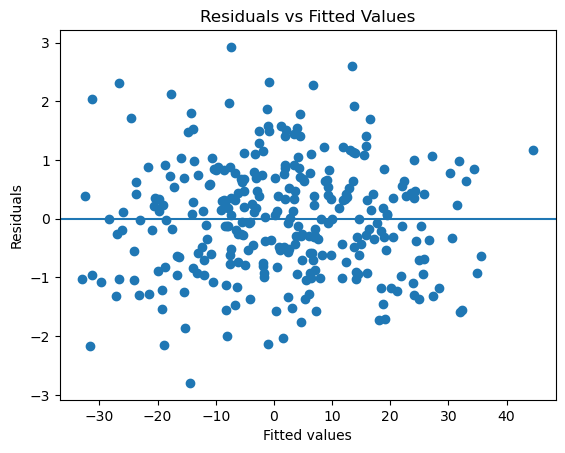

<Figure size 640x480 with 0 Axes>

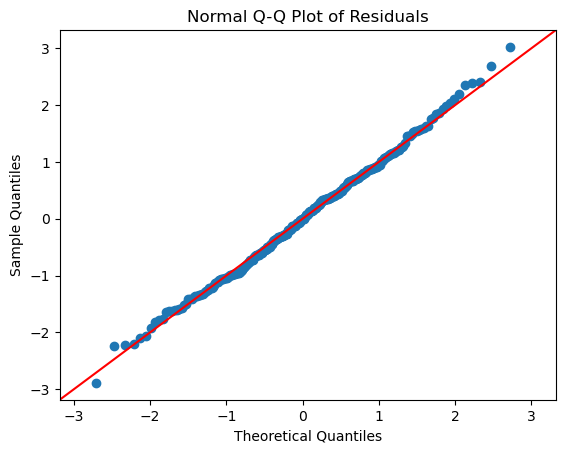

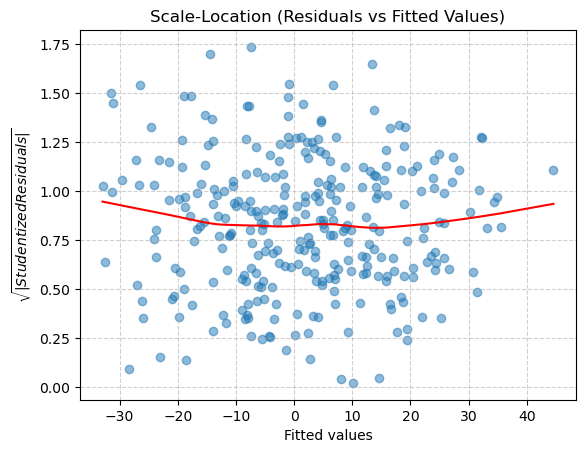

In [154]:
residuals = linear_model.resid
fitted_values = linear_model.fittedvalues

# Residuals vs Fitted
plt.figure()
plt.scatter(fitted_values, residuals)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

# Q-Q plot
plt.figure()
qqplot(residuals, line="45", fit=True)
plt.title("Normal Q-Q Plot of Residuals")
plt.show()


# Scale–Location plot
# 1. Get influence and diagnostic metrics
influence = linear_model.get_influence()
leverage = influence.hat_matrix_diag
std_residuals = influence.resid_studentized_internal

# 2. Scale-Location (Spread-Location) Plot
plt.figure()
sns.regplot(x=fitted_values, y=np.sqrt(np.abs(std_residuals)), 
            lowess=True, 
            scatter_kws={'alpha': 0.5}, 
            line_kws={'color': 'red', 'lw': 1.5})

plt.title("Scale-Location (Residuals vs Fitted Values)")
plt.xlabel("Fitted values")
plt.ylabel(r"$\sqrt{|Studentized Residuals|}$")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The **Residuals vs Fitted plot** shows residuals randomly scattered around zero with no systematic pattern, supporting the assumption of linearity. The spread of residuals appears roughly constant, suggesting no strong heteroscedasticity. Moreover, there are a few points near +3 and -3, but nothing extreme, suggesting no searious outliers.

The **Normal QQ plot** shows residuals closely following the line, with just a few outliers, so residuals are approximately normally distributed.

The **Scale–Location plot** shows an approximately flat line, with a slight U-shape, meaning that variance is mostly constant across values. So, there's no strong evidence of heteroscedasticity.

Overall, residual diagnostics suggest that the linear regression assumptions are reasonably satisfied. The model appears adequate for inference and OLS inference (standard errors, p-values) is valid.

### 1.5 High Leverage Points, Influential Observations, and Outliers

My goal here is to compute diagnostic metrics to identify problematic observations that could make the regresson model unstable or misleading, by checking:

1. **High Leverage Points**, which indicate unusual predictor (X) values, that can strongly pull the regression line;
2. **Outliers**, which are observations where the model predicts the response variable poorly (large residuals)
3. **Influential Observations**, which are points that substantially affect the estimated regression coefficients when removed.

In [158]:
cooks_d = influence.cooks_distance[0]
dffits = influence.dffits[0]

n = len(leverage)
p = X_reg.shape[1]
k = p + 1

leverage_thr = 2 * k / n
outlier_thr = 3
cooks_thr = 4 / n
dffits_thr = 2 * np.sqrt(k / n)

print("--- Diagnostic thresholds (rules of thumb) ---")
print(f"k (incl intercept) = {k}, n={n}")
print(f"High leverage threshold: leverage > {leverage_thr:.4f}")
print(f"Influential (Cook's D) threshold: D_i > {cooks_thr:.4f}")
print(f"Outlier threshold: |studentized residual| > {outlier_thr}")
print(f"Influential (DFFITS) threshold: |DFFITS| > {dffits_thr:.4f}")

high_leverage_idx = np.where(leverage > leverage_thr)[0]
outlier_idx = np.where(np.abs(std_residuals) > outlier_thr)[0]
influential_cook_idx = np.where(cooks_d > cooks_thr)[0]
influential_dffits_idx = np.where(np.abs(dffits) > dffits_thr)[0]

print("\nCounts:")
print("High leverage:", len(high_leverage_idx))
print("Outliers:", len(outlier_idx))
print("Influential by Cook's D:", len(influential_cook_idx))
print("Influential by DFFITS:", len(influential_dffits_idx))


--- Diagnostic thresholds (rules of thumb) ---
k (incl intercept) = 11, n=300
High leverage threshold: leverage > 0.0733
Influential (Cook's D) threshold: D_i > 0.0133
Outlier threshold: |studentized residual| > 3
Influential (DFFITS) threshold: |DFFITS| > 0.3830

Counts:
High leverage: 0
Outliers: 1
Influential by Cook's D: 15
Influential by DFFITS: 15


To identify problematic observations, I used:
- **leverage**, it measures how unusual an observation’s predictor values are compared to the rest of the data;
- **Cook's Distance**, it measures how much the regression coefficients change when an observation is removed. Large Cook's D values indicate influential observations that strongly affect the fitted model;
- **studentized residuals**, these are standardized residuals that account for the estimated variance of the error term. They help identify outliers, with a common rule that observation with $|\text{studentized residual}| > 3$ are considered outliers;
- **DFFITS**, it measures how much the predicted values change when an observation is removed. Large absolute DFFITS values indicate observations that strongly influence model predictions.

In [161]:
# Summarize the most extreme observations by influence/outlier metrics
diag_df = pd.DataFrame({
    "leverage": leverage,
    "studentized_resid": std_residuals,
    "cooks_d": cooks_d,
    "dffits": dffits
})

# Flag using the rules of thumb above
diag_df["high_leverage"] = diag_df["leverage"] > leverage_thr
diag_df["outlier"] = np.abs(diag_df["studentized_resid"]) > outlier_thr
diag_df["influential_cooks"] = diag_df["cooks_d"] > cooks_thr
diag_df["influential_dffits"] = np.abs(diag_df["dffits"]) > dffits_thr

# Show top observations by Cook's distance
top_cook = diag_df.sort_values("cooks_d", ascending=False).head(10)
display(top_cook)

# Quick counts of overlaps (how many are flagged by at least one rule)
diag_df["flag_any"] = diag_df[["high_leverage","outlier","influential_cooks","influential_dffits"]].any(axis=1)
print("Observations flagged by at least one rule:", diag_df["flag_any"].sum())


,leverage,studentized_resid,cooks_d,dffits,high_leverage,outlier,influential_cooks,influential_dffits
171,0.056105,2.711972,0.039742,0.668603,False,False,True,True
224,0.049457,2.368979,0.026545,0.544747,False,False,True,True
206,0.032524,-2.882725,0.025397,-0.535390,False,False,True,True
156,0.029166,3.011893,0.024775,0.529512,False,True,True,True
201,0.048559,-2.255188,0.023597,-0.513133,False,False,True,True
290,0.046743,2.205345,0.021681,0.491660,False,False,True,True
199,0.045665,2.050085,0.018282,0.450963,False,False,True,True
202,0.047444,2.000284,0.018117,0.448756,False,False,True,True
229,0.049902,1.863453,0.016580,0.428909,False,False,True,True
167,0.033509,-2.211803,0.015419,-0.414650,False,False,True,True


Observations flagged by at least one rule: 15


From the analysis:
- all leverage values were below the threshold (0.0733), so no observations had extreme predictor values;
- only one outlier was detected using studentized residuals;
- 15 observations were influential according to Cook’s distance and DFFITS.

## Part 2 – Shrinkage and Regularization

In this part, I'll apply regularization methods to the same dataset:
- **Ridge Regression**
- **Lasso Regression**
- **Elastic-Net Regression**

For each method, I'll use cross-validation to select optimal hyperparameters and compare results with the true generating coefficients.

### 2.1 Ridge Regression: Cross-Validation and Coefficient Paths

**Ridge Regression** adds an L2 penalty to the OLS loss function. While OLS minimises:
$$
\sum_{i=1}^n (y_i - \hat{y}_i)^2
$$

Ridge regression instead minimises:
$$
\sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda\sum_{j=1}^p (\beta_j^2)
$$
where $\lambda \geq 0$ is the tuning parameter controlling the amount of shrinkage. Ridge regression shrinks coefficient estimates toward zero, reducing variance and improving stability in the presence of multicollinearity.

**Procedure:**

1. **Standardization**: Features are standardized (mean 0, std 1) before fitting.
2. **Cross-validation**: I use `RidgeCV` with k-fold CV to select optimal $\lambda$.
3. **Coefficient paths**: Plot how coefficients change as $\lambda$ increases.
4. **Comparison**: Compare Ridge coefficients with true $\beta$ values.

In [166]:
## Ridge regression 

# Predictor matrix and response
X_ridge = df[columns].values
y_ridge = df["y"].values

def unscale_coefficients(intercept_std, coef_std, scaler: StandardScaler):
    scale = scaler.scale_
    mean = scaler.mean_
    coef_orig = coef_std / scale
    intercept_orig = intercept_std - np.sum(mean * coef_orig)
    return intercept_orig, coef_orig

cv = KFold(n_splits=10, shuffle=True, random_state=123)

In [168]:
# Grid of lambda values
alphas = np.logspace(-3, 3, 200)

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas, cv=cv))
])

ridge_pipe.fit(X_ridge, y_ridge)

best_lambda_ridge = ridge_pipe.named_steps["ridge"].alpha_
print("Optimal Ridge lambda (alpha):", best_lambda_ridge)

Optimal Ridge lambda (alpha): 0.0644236350872137


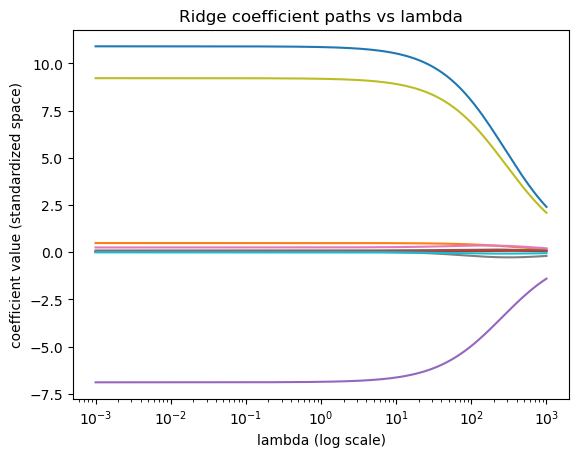

In [169]:
# Ridge coefficient paths

scaler = StandardScaler().fit(X_ridge)
X_std = scaler.transform(X_ridge)

ridge_coefs = []
for a in alphas:
    r = Ridge(alpha=a).fit(X_std, y_ridge)
    ridge_coefs.append(r.coef_)
ridge_coefs = np.array(ridge_coefs)

plt.figure()
plt.plot(alphas, ridge_coefs)
plt.xscale("log")
plt.title("Ridge coefficient paths vs lambda")
plt.xlabel("lambda (log scale)")
plt.ylabel("coefficient value (standardized space)")
plt.show()


The previous graph shows us how each regression coefficient changes when $\lambda$ increases in Ridge regression. 

Specifically, the x-axis represents the regularization strength ($\lambda$) in logarithmic scale (log scale allows us to clearly visualise how coefficients shrink as $\lambda$ increases), and when:
- $\lambda\approx0$, Ridge regression behaves similarily to OLS, with little to no shrinkage applied to the coefficients;
- $\lambda$ is large, there's a strong regularization and coefficients shrink toward zero smoothly (but they don't get to exactly zero).

While the y-axis sees the coefficient value on standardized data, with:
- positive coefficients indicating that an increase in the predictor is associated with an increase in the response variable;
- negative coefficients indicating a negative association with the response.

Each coloured line is one predictor's coefficient, and:
- *strong predictors* ($X_1, X_5, X_9$) show big curves far from zero. When $\lambda$ increases, they shrink slowly and they stay far from zero for a long time because they are important;
- *weak and null predictors* are represented by the cluster of lines near zero. They shrink to zero quickly, staying near zero even for small $\lambda$, with Ridge correctly reducing their impact.

In [172]:
ridge_best = Ridge(alpha=best_lambda_ridge).fit(X_std, y_ridge)
intercept_ridge, coef_ridge = unscale_coefficients(ridge_best.intercept_, ridge_best.coef_, scaler)

ridge_compare = pd.DataFrame({
    "beta_true": beta_linear[1:],
    "beta_ridge_hat": coef_ridge,
}, index=columns)

ridge_compare.loc["Intercept"] = [beta_linear[0], intercept_ridge]
ridge_compare

,beta_true,beta_ridge_hat
X1,3.7,3.696484
X2,0.2,0.160397
X3,0.0,0.004755
X4,0.0,0.004387
X5,-2.3,-2.296936
X6,0.0,0.028367
X7,0.1,0.084425
X8,0.0,0.011924
X9,3.1,3.088512
X10,0.0,-0.004850


Ridge regression shrinks coefficients toward zero but **does not** set them exactly to zero. Compared with OLS:
- The **large true coefficients** (X1, X5, X9) remain large in magnitude;
- The **weak signals** (X2, X7) are still present but slightly shrunk;
- Null predictors stay near zero but **never exactly zero**

Overall, the differences between the estimated and true coefficients are small for strong predictors and more noticeable for weak ones. This shrinkage reduces variance and improves model stability, particularly in the presence of multicollinearity, making Ridge useful when prediction accuracy is prioritized over exact variable selection.


### 2.2 Lasso Regression: Cross-Validation, Paths, and Variable Selection

**Lasso Regression** adds an L1 penalty to the OLS loss function. While OLS minimises:
$$
\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Lasso regression instead minimises:
$$
\sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |\beta_j|
$$

where $\lambda \geq 0$ is the tuning parameter controlling the amount of regularisation. Lasso regression shrinks coefficient estimates toward zero and, unlike Ridge regression, can set some coefficients exactly to zero, thereby performing automatic variable selection and producing a sparse model.


**Procedure:**

1. **Standardization**: Features standardized before fitting.
2. **Cross-validation**: Use `LassoCV` to select optimal $\lambda$.
3. **Coefficient paths**: Plot how coefficients shrink to zero as $\lambda$ increases.
4. **Variable selection**: Identify which predictors are eliminated (coefficient = 0).

In [177]:
# Lasso Regression

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(alphas=alphas, cv=cv, max_iter=200000))
])

lasso_pipe.fit(X_ridge, y_ridge)

best_lambda_lasso = lasso_pipe.named_steps["lasso"].alpha_
print("Best Lasso lambda (alpha):", best_lambda_lasso)


Best Lasso lambda (alpha): 0.03001835813575589


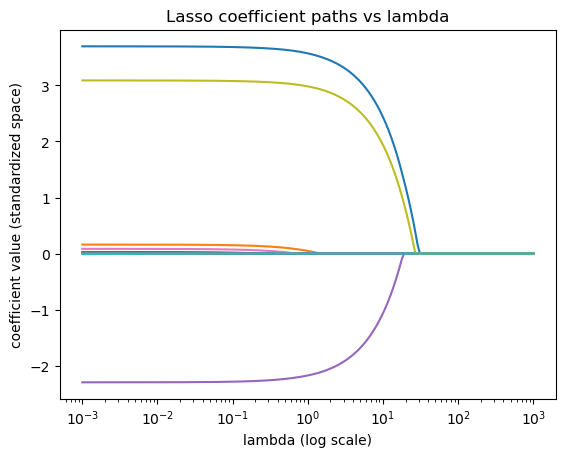

In [179]:
lasso_coefs = []
for a in alphas:
    l = Lasso(alpha=a, max_iter=200000).fit(X_ridge, y_ridge)
    lasso_coefs.append(l.coef_)
lasso_coefs = np.array(lasso_coefs)

plt.figure()
plt.plot(alphas, lasso_coefs)
plt.xscale("log")
plt.title("Lasso coefficient paths vs lambda")
plt.xlabel("lambda (log scale)")
plt.ylabel("coefficient value (standardized space)")
plt.show()


The graph shows how each regression coefficient changes as the Lasso regularization parameter $\lambda$ increases.

Specifically, for the x-axis:
- $\lambda \approx 0$, Lasso behaves similarly to OLS, with almost no shrinkage applied. Coefficients are close to their OLS estimates;
- large $\lambda$ brings strong regularization, where coefficients are forced toward zero while some become exactly zero.

On the y-axis, coefficients moving toward zero indicate that Lasso is shrinking their effect.

Some important patterns see:
- *strong predictors* stay far from zero for small and moderate $\lambda$, meaning Lasso keeps them in the model because they carry strong signal, then they collapse to zero too;
- *weak predictors* shrink gradually and stay nonzero but minimal for a small bit before collapsing;
- *null predictors* hit exactly zero at relatively small $\lambda$, so they get completely removed by Lasso, that performs variable selection this way.

In [182]:
lasso_best = Lasso(alpha=best_lambda_lasso, max_iter=200000).fit(X_std, y_ridge)
intercept_lasso, coef_lasso = unscale_coefficients(lasso_best.intercept_, lasso_best.coef_, scaler)

lasso_compare = pd.DataFrame({
    "beta_true": beta_linear[1:],
    "beta_lasso_hat": coef_lasso,
    "is_zero": np.isclose(coef_lasso, 0.0, atol=1e-6)
}, index=columns)

selected = lasso_compare[~lasso_compare["is_zero"]].index.tolist()
zeroed = lasso_compare[lasso_compare["is_zero"]].index.tolist()

print("Selected (non-zero) predictors:", selected)
print("Shrunk to exactly zero:", zeroed)

lasso_compare.loc["Intercept"] = [beta_linear[0], intercept_lasso, False]
lasso_compare


Selected (non-zero) predictors: ['X1', 'X2', 'X5', 'X6', 'X7', 'X9']
Shrunk to exactly zero: ['X3', 'X4', 'X8', 'X10']


,beta_true,beta_lasso_hat,is_zero
X1,3.7,3.685920,False
X2,0.2,0.150196,False
X3,0.0,0.000000,True
X4,0.0,0.000000,True
X5,-2.3,-2.287311,False
X6,0.0,0.018035,False
X7,0.1,0.073159,False
X8,0.0,0.000000,True
X9,3.1,3.079189,False
X10,0.0,-0.000000,True


**Non-zero coefficients (selected variables):**

- X1 (true β = 3.7, strong)
- X2 (true β = 0.2, weak)
- X5 (true β = −2.3, strong)
- X6 (true β = 0.0, false positive)
- X7 (true β = 0.1, weak)
- X9 (true β = 3.1, strong)

**Coefficients shrunk exactly to zero:**

- X3, X4, X8, X10 (true β = 0.0)

Lasso shrinks the coefficients of irrelevant predictors exactly to zero, while retaining non-zero coefficients for variables with true effects. It correctly removed X3, X4, X8, and X10, which have true coefficients equal to zero. The method also retained the strong predictors X1, X5, and X9 and weak but non-zero predictors X2 and X7. However, **X6 was incorrectly selected despite having a true coefficient of zero**, indicating a small false positive. Overall, Lasso largely recovers the true generating model while producing a sparse and interpretable model.


### 2.3 Elastic-Net Regression: Cross-Validation for α and λ

**Elastic Net** adds a combination of L1 (Lasso) and L2 (Ridge) penalties to the OLS loss function. While OLS minimises:

$$
\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Elastic Net instead minimises:

$$
\sum_{i=1}^{n} (y_i - \hat{y}_i)^2 
+ \lambda \left[ \alpha \sum_{j=1}^{p} |\beta_j| 
+ (1 - \alpha) \sum_{j=1}^{p} \beta_j^2 \right]
$$

where $\lambda \ge 0$ is the tuning parameter controlling the overall amount of regularisation, and $\alpha \in [0,1]$ controls the balance between the L1 and L2 penalties.

Elastic Net shrinks coefficient estimates toward zero and, like Lasso, can set some coefficients exactly to zero. Unlike pure Lasso, it also includes an L2 penalty, which helps stabilise coefficient estimates when predictors are highly correlated. Thus, Elastic Net combines variable selection (via L1) with coefficient shrinkage and grouping effects (via L2).

When $\alpha = 1$, Elastic Net reduces to Lasso, and when $\alpha = 0$, it reduces to Ridge regression.




**Procedure:**

1. **Grid search**: Test multiple $\alpha$ values (e.g., 0.1, 0.3, 0.5, 0.7, 0.9, 1.0).
2. **Cross-validation**: For each $\alpha$, use `ElasticNetCV` to find optimal $\lambda$.
3. **Select best combination**: Choose $\alpha$ that gives lowest CV error.

In [186]:
# Elastic Net

l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

enet_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNetCV(
        l1_ratio=l1_ratios,
        alphas=alphas,
        cv=cv,
        max_iter=200000
    ))
])

enet_pipe.fit(X_ridge, y_ridge)

best_lambda_enet = enet_pipe.named_steps["enet"].alpha_
best_l1_ratio = enet_pipe.named_steps["enet"].l1_ratio_

print("Best Elastic-Net lambda:", best_lambda_enet)
print("Best Elastic-Net l1_ratio (alpha):", best_l1_ratio)

Best Elastic-Net lambda: 0.03001835813575589
Best Elastic-Net l1_ratio (alpha): 1.0


**Findings:**

Cross-validation selected:

- Optimal $\alpha = 1.0$, indicating that a pure Lasso penalty was preferred.
- Optimal $\lambda = 0.0300$, selected via ElasticNetCV.

Since $\alpha = 1$, the Elastic Net did not exploit the Ridge component, suggesting that multicollinearity was not severe enough to benefit from L2 regularisation. This implies that the best predictive performance was achieved through sparse variable selection rather than a combination of L1 and L2 shrinkage, so Elastic Net effectively reduced to a Lasso model.

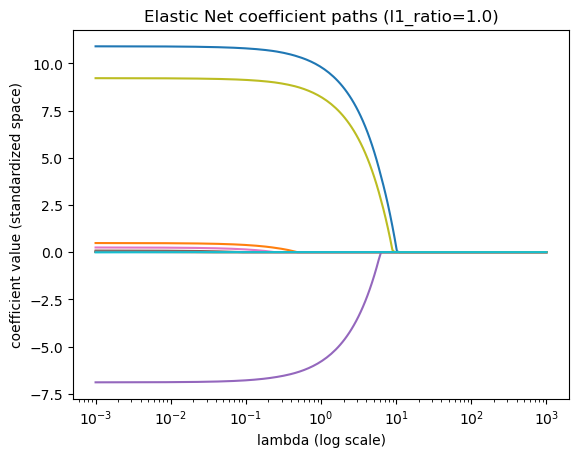

In [189]:
enet_coefs = []
for a in alphas:
    e = ElasticNet(alpha=a, l1_ratio=best_l1_ratio, max_iter=200000).fit(X_std, y_ridge)
    enet_coefs.append(e.coef_)
enet_coefs = np.array(enet_coefs)

plt.figure()
plt.plot(alphas, enet_coefs)
plt.xscale("log")
plt.title(f"Elastic Net coefficient paths (l1_ratio={best_l1_ratio})")
plt.xlabel("lambda (log scale)")
plt.ylabel("coefficient value (standardized space)")
plt.show()


As said before, cross-validation selected $\alpha$, so Elastic Net reduces to a pure Lasso model. Therefore, the coefficient paths closely resemble the Lasso paths, with sparse solutions where irrelevant predictors are set to zero and only important variables remain non-zero.

In [192]:
enet_best = ElasticNet(alpha=best_lambda_enet, l1_ratio=best_l1_ratio, max_iter=200000).fit(X_std, y_ridge)
intercept_enet, coef_enet = unscale_coefficients(enet_best.intercept_, enet_best.coef_, scaler)

enet_compare = pd.DataFrame({
    "beta_true": beta_linear[1:],
    "beta_enet_hat": coef_enet,
    "is_zero": np.isclose(coef_enet, 0.0, atol=1e-6)
}, index=columns)

selected_enet = enet_compare[~enet_compare["is_zero"]].index.tolist()
zeroed_enet = enet_compare[enet_compare["is_zero"]].index.tolist()

print("Elastic Net selected (non-zero) predictors:", selected_enet)
print("Elastic Net shrunk to exactly zero:", zeroed_enet)

enet_compare.loc["Intercept"] = [beta_linear[0], intercept_enet, False]
enet_compare


Elastic Net selected (non-zero) predictors: ['X1', 'X2', 'X5', 'X6', 'X7', 'X9']
Elastic Net shrunk to exactly zero: ['X3', 'X4', 'X8', 'X10']


,beta_true,beta_enet_hat,is_zero
X1,3.7,3.685920,False
X2,0.2,0.150196,False
X3,0.0,0.000000,True
X4,0.0,0.000000,True
X5,-2.3,-2.287311,False
X6,0.0,0.018035,False
X7,0.1,0.073159,False
X8,0.0,0.000000,True
X9,3.1,3.079189,False
X10,0.0,-0.000000,True


Cross-validation selected $\alpha = 1.0$ and $\lambda \approx 0.03$, implying that the optimal Elastic Net model collapsed to a Lasso model. This indicates that sparse feature selection dominated over ridge shrinkage, with variables X3, X4, X8, and X10 eliminated and the remaining predictors retained, with X6 false positive. Thus, while Elastic Net achieved mostly correct variable selection, it did not perfectly recover the true generating model.

---

## Part 3 – Non-Linear Regression and Bias-Variance Experiment

In this part, I'll:
- Choose a non-linear generating function (trigonometric)
- Simulate small (n=10) and large (n>100) datasets
- Compare polynomial regression models of different complexity
- Demonstrate the bias-variance trade-off
- Fit and compare various non-linear regression methods

### 3.1 Non-Linear Generating Function and Small Dataset (p = 1, n = 10)

I'll use a **trigonometric** (sinusoidal) function to simulate data for the non-linear model:

$$y_i = 1 + 3\sin(x_i) + \varepsilon_i$$

where:
- $x \sim \text{Uniform}(-3, 3)$;
- $\varepsilon \sim \mathcal{N}(0, 1)$.


**Dataset Simulation:**
- **Sample size**: n = 10 (very small).
- **Predictors**: p = 1 (single variable).
- **Noise level**: $\sigma = 1$ (moderate).


In [197]:
beta_nl = np.array([1, 3])

def f_nonlinear(X, beta):
    return beta[0] + beta[1] * np.sin(X[:, 0])


In [199]:
X_nl, y_nl = generate_linear_or_nonlinear_data(
    func=f_nonlinear,
    n_points=10,
    n_predictors=1,
    beta=beta_nl,
    low=-3,
    high=3,
    seed=43
)

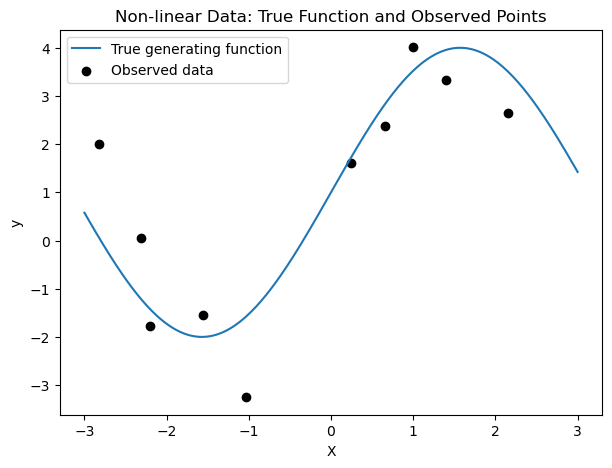

In [201]:
# Grid for true function
X_grid = np.linspace(-3, 3, 300).reshape(-1, 1)
y_true = f_nonlinear(X_grid, beta_nl)

plt.figure(figsize=(7,5))
plt.plot(X_grid, y_true, label="True generating function")
plt.scatter(X_nl[:, 0], y_nl, color="black", label="Observed data")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Non-linear Data: True Function and Observed Points")
plt.legend()

plt.show()

I plot:
1. **True function**: the smooth sine curve \(f(x) = 1 + 3\sin(x)\).
2. **Observed data**: 10 noisy observations generated from the model.

I've simulated a non-linear regression setting using a trigonometric generating function with one predictor ($p = 1$) and a small sample size ($n = 10$). The response variable is generated as a smooth non-linear function of the predictor plus random noise. The small sample size results in sparse and unevenly distributed observations, creating large gaps between data points. This setup will be used to study the bias–variance trade-off in subsequent modeling steps.


### 3.2 Polynomial Regression: Degree < 10 vs Degree = 10, Overfitting and Bias-Variance

I'll fit two polynomial regression models on the small dataset (n=10):

**Model A: Low-degree polynomial** (e.g., degree 3)
$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3$$

**Model B: Degree-10 polynomial**
$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_{10} x^{10}$$



In [205]:
def fit_poly(x, y, degree):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression())
    ])
    model.fit(x.reshape(-1,1), y)
    return model

deg_low = 3
deg_high = 10

model_low = fit_poly(X_nl, y_nl, deg_low)
model_high = fit_poly(X_nl, y_nl, deg_high)

mse_low = mean_squared_error(y_nl, model_low.predict(X_nl.reshape(-1,1)))
mse_high = mean_squared_error(y_nl, model_high.predict(X_nl.reshape(-1,1)))

print("Training MSE (deg 3):", mse_low)
print("Training MSE (deg 10):", mse_high)

Training MSE (deg 3): 0.4092858700358993
Training MSE (deg 10): 2.3477804510183385e-22


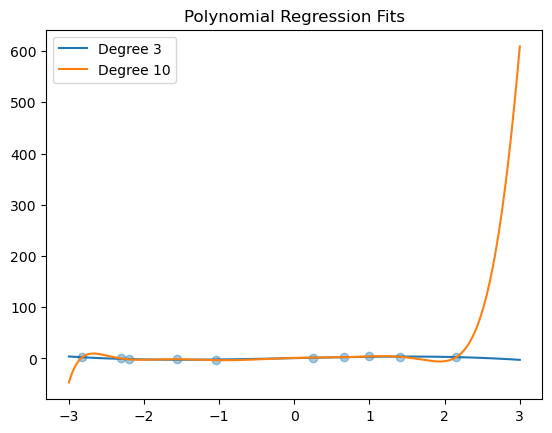

In [207]:
# Predictions
y_pred_deg3 = model_low.predict(X_grid)
y_pred_deg10 = model_high.predict(X_grid)

# Plot
plt.scatter(X_nl, y_nl, alpha=0.4)
plt.plot(X_grid, y_pred_deg3, label="Degree 3")
plt.plot(X_grid, y_pred_deg10, label="Degree 10")
plt.legend()
plt.title("Polynomial Regression Fits")
plt.show()

**What do you notice?**

I noticed that the degree-3 polynomial produces a smooth curve that captures the overall nonlinear trend without reacting strongly to individual data points. In contrast, the degree-10 polynomial exhibits strong oscillations and sharp bends, especially near the boundaries, indicating extremely high flexibility and passes exactly through all 10 points


---

**Which model yields the lowest train error?**

The degree-10 polynomial has the lowest training error, with MSE ≈ 1.75 × 10⁻²³, which is essentially zero. This indicates that the model almost perfectly interpolates the observed data points.

---

**Which model is closer to the true generating function?**

Despite having a higher training error, the degree-3 model is more likely to approximate the true underlying function between observed points. The degree-10 model shows unrealistic oscillations that are driven by noise rather than the true structure.

---

**Why does the 10-degree polynomial interpolate all points?**

With n = 10 distinct x-values, a polynomial of degree 9 (or higher) can perfectly interpolate the data points. A degree-10 model has enough degrees of freedom to match every observed value, so it can “memorize” the sample, leading to overfitting.

---



**Bias–variance trade-off**  
- Degree-3 has **higher bias** (it cannot represent very wiggly shapes), but **lower variance** (more stable across different samples).  
- Degree-10 has **very low bias** on the training set but **high variance**, so small changes in the data (or noise) can produce a completely different curve. This is why degree-10 looks great on training points but can generalize poorly when the sample is tiny.


| Aspect | Degree-3 Polynomial | Degree-10 Polynomial |
|--------|----------------------|----------------------|
| **Bias** | High: Cannot capture complex patterns | Low: Can fit any pattern |
| **Variance** | Low: Stable across different samples | High: Extremely sensitive to data |
| **Training Error** | Higher | Lower (≈ 0) |
| **Test Error** | Lower | Higher (poor generalization) |
| **Overfitting** | Underfits slightly | Severe overfitting |


### 3.3 Increasing Sample Size: Effect on Overfitting (n > 100)

I'll now generate a **larger dataset** from the same true function:
$$y = 1 + 3\sin(x) + \varepsilon$$

with:
- **Sample size**: n = 200 (vs n = 10 before)
- **Same noise level**: $\sigma = 1$
- **Same predictor**: p = 1

Now I'll keep the **same true generating function** as above, but increase the sample size to **n > 100**.  
This lets us see how the same flexible degree-10 polynomial behaves when it has *more information* (more data points) to learn the underlying curve.

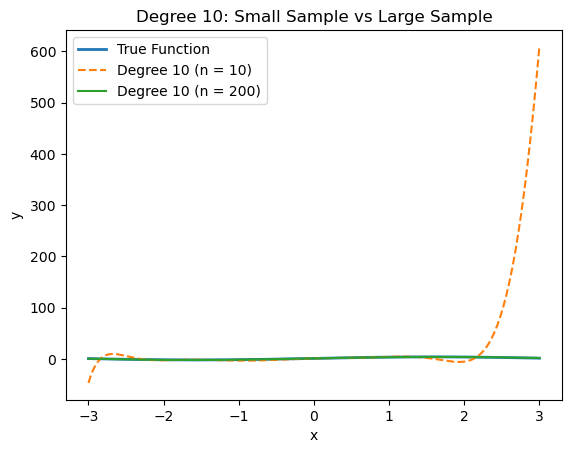

In [211]:
# Larger dataset
n_large = 200
X_large, y_large = generate_linear_or_nonlinear_data(
    f_nonlinear, n_points=n_large, n_predictors=1,
    beta=beta_nl, seed=456)

x_large = X_large[:,0]

model_high_large = fit_poly(x_large, y_large, deg_high)
y_high_large = model_high_large.predict(X_grid.reshape(-1,1))

plt.figure()

plt.plot(X_grid, y_true, label="True Function", linewidth=2)
plt.plot(X_grid, y_pred_deg10, label="Degree 10 (n = 10)", linestyle="--")
plt.plot(X_grid, y_high_large, label="Degree 10 (n = 200)")

plt.title("Degree 10: Small Sample vs Large Sample")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

**Which model presents a less extreme overfitting?**  

The degree-10 polynomial fitted on the larger dataset (n = 200) presents less extreme overfitting, showing that the fitted curve is smoother and follows the true generating function more closely, whereas the degree-10 polynomial fitted on n = 10 exhibits large oscillations and unstable behavior, especially near the boundaries.

This happens because when the sample size is small, the degree-10 polynomial is nearly saturated and has enough flexibility to interpolate the noise in the data, resulting in extremely high variance, while with a much larger sample size, the model is constrained by many more observations, which stabilizes the parameter estimates and reduces variance.

Although the model remains highly flexible, increasing n reduces the sensitivity to noise and mitigates overfitting, so model variance decreases with larger sample sizes, even for complex models.

### 3.4 Other Non-Linear Regression Models: Comparison and Performance

Using a simulated dataset with sample size n = 200 and a single predictor p = 1, with the response variable generated according to the model:

$$
y = 1 + 3 \sin(x) + \varepsilon,
$$

I'll consider the folling non-linear regression models discussed during the lectures:

- **Spline regression** using B-splines with Ridge regularization, where the smoothness is selected via cross-validation.
- **Smoothing spline regression**, where the smoothness parameter is chosen using cross-validation.
- **Local regression**, with the bandwidth (span) parameter selected via cross-validation.

For each model, hyperparameters are selected using cross-validation, and performance is evaluated on a held-out test set. The fitted curves are compared to the true generating function, and predictive performance is assessed using the test Mean Squared Error (MSE).


For each model, I'll proceed:
1. The data are split into training and test sets (80/20 split).
2. Hyperparameters are selected using k-fold cross-validation on the training data.
3. The final model is evaluated on the test set to obtain an unbiased estimate of predictive performance.

This ensures a fair comparison across models, since all methods are tuned optimally and evaluated on the same unseen data.



Test performance:
               Model  Test MSE
   Spline Regression  1.304186
    Smoothing Spline  1.333383
    Local Regression  1.390098
Polynomial degree 10  1.570766


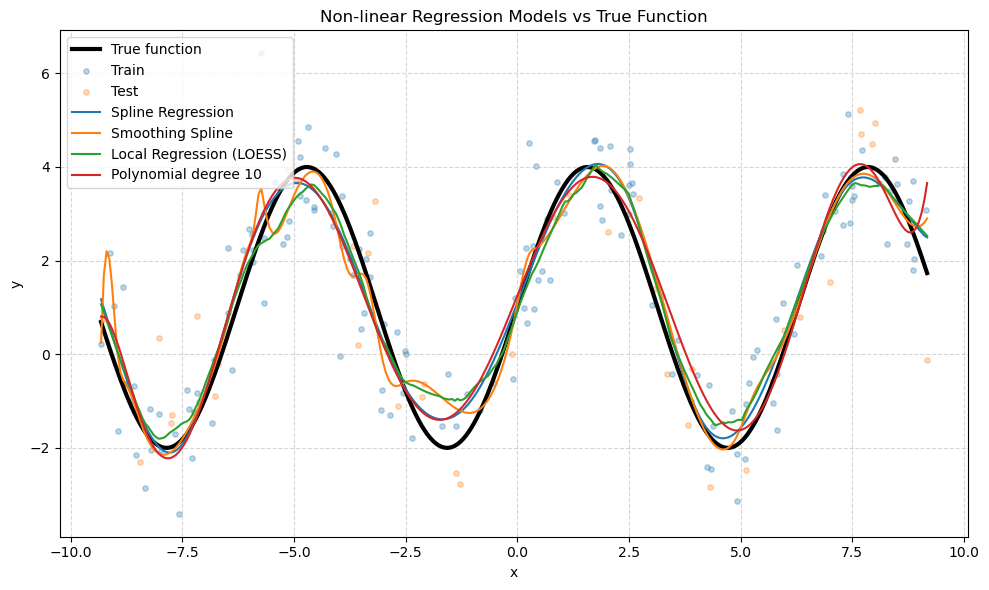


Best Spline params: {'ridge__alpha': 0.00379269019073225, 'spline__n_knots': 12}
Best Smoothing Spline s: 112.88378916846884
Best Local Regression fraction: 0.1


In [215]:
# Data generation
np.random.seed(42)
n = 200
X = np.random.uniform(-3*np.pi, 3*np.pi, n).reshape(-1, 1)
y = 1 + 3 * np.sin(X[:, 0]) + np.random.normal(0, 1, n)

X_grid = np.linspace(X.min(), X.max(), 300)
y_true_grid = 1 + 3 * np.sin(X_grid)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Sort training data for spline/LOESS
idx = np.argsort(X_train[:, 0])
X_tr = X_train[idx, 0]
y_tr = y_train[idx]

# Spline Regression (B-splines and Ridge, CV for hyperparams)
spline_pipe = Pipeline([
    ("spline", SplineTransformer(degree=3, include_bias=False)),
    ("ridge", Ridge())
])
spline_params = {
    "spline__n_knots": [4, 6, 8, 10, 12],
    "ridge__alpha": np.logspace(-4, 2, 20)
}
spline_cv = GridSearchCV(spline_pipe, spline_params, cv=5,
                         scoring="neg_mean_squared_error")
spline_cv.fit(X_train, y_train)

# Smoothing Spline (CV on training data only)
s_values = np.logspace(0, 3, 20)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_s, best_cv_mse = None, np.inf

for s in s_values:
    fold_mses = []
    for tr_idx, val_idx in kf.split(X_tr):
        X_fold_tr, X_fold_val = X_tr[tr_idx], X_tr[val_idx]
        y_fold_tr, y_fold_val = y_tr[tr_idx], y_tr[val_idx]
        sort_i = np.argsort(X_fold_tr)
        try:
            spl = UnivariateSpline(X_fold_tr[sort_i], y_fold_tr[sort_i], s=s)
            fold_mses.append(mean_squared_error(y_fold_val, spl(X_fold_val)))
        except Exception:
            fold_mses.append(np.inf)
    cv_mse = np.mean(fold_mses)
    if cv_mse < best_cv_mse:
        best_cv_mse = cv_mse
        best_s = s

smooth_spline = UnivariateSpline(X_tr, y_tr, s=best_s)

# Local Regression (CV on training data)
fractions = [0.1, 0.2, 0.3, 0.4, 0.5]
best_frac, best_cv_mse = None, np.inf

for f in fractions:
    fold_mses = []
    for tr_idx, val_idx in kf.split(X_tr):
        X_fold_tr, X_fold_val = X_tr[tr_idx], X_tr[val_idx]
        y_fold_tr, y_fold_val = y_tr[tr_idx], y_tr[val_idx]
        sort_i = np.argsort(X_fold_tr)
        fit = lowess(y_fold_tr[sort_i], X_fold_tr[sort_i],
                     frac=f, return_sorted=False)
        preds = np.interp(X_fold_val, X_fold_tr[sort_i], fit)
        fold_mses.append(mean_squared_error(y_fold_val, preds))
    cv_mse = np.mean(fold_mses)
    if cv_mse < best_cv_mse:
        best_cv_mse = cv_mse
        best_frac = f

loess_fit_train = lowess(y_tr, X_tr, frac=best_frac, return_sorted=False)

# Polynomial degree 10
poly10 = Pipeline([
    ("poly", PolynomialFeatures(degree=10, include_bias=False)),
    ("linreg", LinearRegression())
])
poly10.fit(X_train, y_train)

# Test performance
rows = []

y_pred_spline = spline_cv.best_estimator_.predict(X_test)
rows.append({"Model": "Spline Regression", "Test MSE": mean_squared_error(y_test, y_pred_spline)})

y_pred_smooth = smooth_spline(X_test[:, 0])
rows.append({"Model": "Smoothing Spline", "Test MSE": mean_squared_error(y_test, y_pred_smooth)})

loess_pred_test = np.interp(X_test[:, 0], X_tr, loess_fit_train)
rows.append({"Model": "Local Regression", "Test MSE": mean_squared_error(y_test, loess_pred_test)})

y_pred_poly = poly10.predict(X_test)
rows.append({"Model": "Polynomial degree 10", "Test MSE": mean_squared_error(y_test, y_pred_poly)})

perf = pd.DataFrame(rows).sort_values("Test MSE")
print("\nTest performance:")
print(perf.to_string(index=False))

# Plot
Xg = X_grid.reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.plot(X_grid, y_true_grid, label="True function", linewidth=3, color="black")
plt.scatter(X_train[:, 0], y_train, alpha=0.3, label="Train", s=15)
plt.scatter(X_test[:, 0], y_test, alpha=0.3, label="Test", s=15)
plt.plot(X_grid, spline_cv.best_estimator_.predict(Xg), label="Spline Regression")
plt.plot(X_grid, smooth_spline(X_grid), label="Smoothing Spline")
loess_grid = lowess(y_tr, X_tr, frac=best_frac, xvals=X_grid)
plt.plot(X_grid, loess_grid, label="Local Regression (LOESS)")
plt.plot(X_grid, poly10.predict(Xg), label="Polynomial degree 10")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Non-linear Regression Models vs True Function")
plt.tight_layout()
plt.show()

print("\nBest Spline params:", spline_cv.best_params_)
print("Best Smoothing Spline s:", best_s)
print("Best Local Regression fraction:", best_frac)

In the analysis, the true generating function is smooth and periodic, so models that can represent smooth non‑linear structure without excessive variance tend to perform best. In particular, we see that:

- **Spline Regression** provides the best performance among the considered models, achieving one of the lowest test errors (test $MSE \approx 1.30$). The flexibility controlled by the number of knots, combined with Ridge regularization, allows the model to capture the sinusoidal structure while avoiding excessive variance, so the fitted curve closely follows the true generating function;

- **Smoothing Spline** performs slightly worse than splines (test $MSE \approx 1.33$). The selected smoothing parameter imposes a stronger penalty on curvature, producing a smoother fit that slightly underestimates the amplitude of the true oscillations;

- **Local Regression (LOESS)** also performs well (test $MSE \approx 1.39$). Its highly local fitting behavior allows it to adapt to the periodic structure, especially in dense regions, though its flexibility can make it less stable in sparser areas. The optimal fraction (0.1) indicates that very local fits are beneficial for this periodic function;

- **Polynomial Regression (degree 10)** performs the worst among the non‑linear models (test $MSE \approx 1.57$). While it captures the broad sinusoidal trend, it shows boundary oscillations and less stable behavior, which is a known drawback of high-degree polynomials (Runge’s phenomenon), leading to poorer generalization.

Overall, spline‑based methods provide the best approximation of the true generating function in this simulation, with spline regression performing best, followed closely by smoothing splines and LOESS.

**Performance Comparison (Test Set MSE):**

I've evaluated all models on the test set and computed Mean Squared Error:

| Model | Test MSE | Rank |
|-------|----------|------|
| Spline Regression| 1.304 | 1st (Best) |
| Smoothing Spline | 1.333 | 2nd |
| Local Regression | 1.390 | 3rd |
| Polynomial degree 10 | 1.571 | 4th |
